In [ ]:
import os

import re
import math
import time
import random
from collections import Counter
import zipfile
from pathlib import Path


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: Tesla T4


In [8]:
train_df = pd.read_csv(r"/kaggle/input/datasets/bhuvanvishaljuturu/english-french/en_fr_train.csv")
val_df = pd.read_csv(r"/kaggle/input/datasets/bhuvanvishaljuturu/english-french/en_fr_val.csv")
test_df = pd.read_csv(r"/kaggle/input/datasets/bhuvanvishaljuturu/english-french/en_fr_test.csv")

# Ensure string types and clean trailing whitespaces
train_df['en'] = train_df['en'].astype(str).str.strip()
train_df['fr'] = train_df['fr'].astype(str).str.strip()
val_df['en'] = val_df['en'].astype(str).str.strip()
val_df['fr'] = val_df['fr'].astype(str).str.strip()
test_df['en'] = test_df['en'].astype(str).str.strip()
test_df['fr'] = test_df['fr'].astype(str).str.strip()
train_df.head()

,en,fr
0,"Thank you so much, Chris. And it's truly a gre...","Merci beaucoup, Chris. C'est vraiment un honne..."
1,"I have been blown away by this conference, and...",J'ai été très impressionné par cette conférenc...
2,"And I say that sincerely, partly because Put ...","Et je dis çà sincèrement, en autres parce que ..."
3,I flew on Air Force Two for eight years.,J'ai volé avec Air Force 2 pendant huit ans.
4,Now I have to take off my shoes or boots to ge...,"Et maintenant, je dois enlever mes chaussures ..."


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232825 entries, 0 to 232824
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   en      232825 non-null  object
 1   fr      232825 non-null  object
dtypes: object(2)
memory usage: 3.6+ MB


In [10]:
len(train_df), len(val_df), len(test_df)

(232825, 890, 8597)

In [11]:
# Special token constants (identical to Subtask 1)
UNK_TOKEN = "<unk>"
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

UNK_IDX = 0
PAD_IDX = 1
SOS_IDX = 2
EOS_IDX = 3

def tokenize(text, lower=True):
    """Splits text into word tokens and punctuation marks."""
    if lower:
        text = text.lower()
    return re.findall(r"\w+|[^\w\s]", text)

class Vocab:
    def __init__(self, name, min_freq=2, max_size=None):
        self.name = name
        self.min_freq = min_freq
        self.max_size = max_size
        self.special_tokens = [UNK_TOKEN, PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
        self.stoi = {tok: idx for idx, tok in enumerate(self.special_tokens)}
        self.itos = {idx: tok for idx, tok in enumerate(self.special_tokens)}

    def build_vocab(self, sentences):
        counter = Counter()
        for sentence in sentences:
            tokens = tokenize(sentence)
            counter.update(tokens)

        sorted_tokens = [w for w, count in counter.most_common() if count >= self.min_freq]
        if self.max_size is not None:
            sorted_tokens = sorted_tokens[: self.max_size - len(self.special_tokens)]

        for token in sorted_tokens:
            if token not in self.stoi:
                idx = len(self.stoi)
                self.stoi[token] = idx
                self.itos[idx] = token

        print(f"Vocab [{self.name}]: {len(self.stoi):,} tokens "
              f"(pruned {len(counter) - len(sorted_tokens):,} rare tokens with freq < {self.min_freq})")

    def numericalize(self, tokens, add_sos=True, add_eos=True):
        ids = []
        if add_sos:
            ids.append(SOS_IDX)
        ids.extend([self.stoi.get(tok, UNK_IDX) for tok in tokens])
        if add_eos:
            ids.append(EOS_IDX)
        return ids

    def decode(self, ids, remove_special=True):
        tokens = []
        for i in ids:
            if isinstance(i, torch.Tensor):
                i = i.item()
            tok = self.itos.get(i, UNK_TOKEN)
            if remove_special and tok in (PAD_TOKEN, SOS_TOKEN, EOS_TOKEN):
                if tok == EOS_TOKEN:
                    break
                continue
            tokens.append(tok)
        return " ".join(tokens)

    def __len__(self):
        return len(self.stoi)

In [12]:
# Build source (English) and target (French) vocabularies from training data
en_vocab = Vocab("English", min_freq=2)
fr_vocab = Vocab("French", min_freq=2)

en_vocab.build_vocab(train_df['en'])
fr_vocab.build_vocab(train_df['fr'])

Vocab [English]: 35,212 tokens (pruned 18,062 rare tokens with freq < 2)
Vocab [French]: 45,266 tokens (pruned 27,166 rare tokens with freq < 2)


In [13]:
class TranslationDataset(Dataset):
    def __init__(self, df, src_vocab, trg_vocab):
        self.src_data = [src_vocab.numericalize(tokenize(text)) for text in df['en']]        
        self.trg_data = [
            trg_vocab.numericalize(tokenize(text)) for text in df['fr']]

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        return self.src_data[idx], self.trg_data[idx]

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)

    src_tensors = [torch.tensor(x, dtype=torch.long) for x in src_batch]
    trg_tensors = [torch.tensor(x, dtype=torch.long) for x in trg_batch]

    src_padded = pad_sequence(src_tensors, batch_first=False, padding_value=PAD_IDX)
    trg_padded = pad_sequence(trg_tensors, batch_first=False, padding_value=PAD_IDX)

    return src_padded, trg_padded

The attention model has a much larger memory footprint than the Exp 1 baseline. At every decoder step it computes attention scores over all source positions and stores those activations for backpropagation, on top of the full output logits (batch × target length × 45,266 vocabulary entries). With the original batch size of 64, training ran out of GPU memory on the 15 GB Kaggle GPU (the failure occurred during the backward pass, when a batch containing long sentences needed an extra 1.28 GiB). To fix this without changing the optimization setup, I split each batch of 64 into two micro-batches of 32 and accumulated gradients over both before each optimizer step. The effective batch size therefore remains 64, with the same number of parameter updates per epoch, and the learning rate, gradient clipping, loss function, number of epochs, and data are the same as in Exp 1. I also used mixed-precision (fp16) training with gradient scaling to reduce memory use and training time. Validation and test evaluation were run in full precision with the original batch size of 64. These choices affect only how the computation is scheduled and are not expected to change the comparison between the two models.

In [14]:
# Create Datasets and DataLoaders
BATCH_SIZE = 64        # effective batch size (same as Exp 1)
MICRO_BATCH = 32       # what actually goes on the GPU
ACCUM_STEPS = BATCH_SIZE // MICRO_BATCH

train_dataset = TranslationDataset(train_df, en_vocab, fr_vocab)
val_dataset = TranslationDataset(val_df, en_vocab, fr_vocab)
test_dataset = TranslationDataset(test_df, en_vocab, fr_vocab)

train_loader = DataLoader(train_dataset, batch_size=MICRO_BATCH, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Model Architecture

## 1. The Encoder
The encoder processes the input sequence $(x_1, x_2, \dots, x_{T_x})$ sequentially. At each time step $i$, it updates its internal state.

$$h_i = \text{LSTM}_{\text{enc}}(x_i, h_{i-1})$$

* **$x_i$**: The input vector (embedding) at source time step $i$.
* **$h_{i-1}$**: The previous encoder hidden state.
* **$h_i$**: The current encoder hidden state. 

*Note: All hidden states $(h_1, h_2, \dots, h_{T_x})$ are preserved to be used by the attention mechanism.*


## 2. Bahdanau (Additive) Attention Mechanism
Instead of passing only the final hidden state to the decoder, Bahdanau attention computes a dynamic **context vector $c_t$** at each decoder time step $t$. It scores how well the inputs around position $i$ match the output at position $t$.


The score evaluates the relevance of the encoder hidden state $h_i$ given the *previous* decoder hidden state $s_{t-1}$.

$$e_{t,i} = v_a^\top \tanh(W_a s_{t-1} + U_a h_i)$$

* **$s_{t-1}$**: The decoder's hidden state from the previous time step.
* **$W_a, U_a$**: Trainable weight matrices.
* **$v_a^\top$**: A trainable weight vector that projects the combined states into a scalar score.


The raw alignment scores are normalized across all source time steps using a Softmax function to create a probability distribution.

$$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_{k=1}^{T_x} \exp(e_{t,k})}$$

* **$\alpha_{t,i}$**: The amount of attention the decoder should pay to the $i$-th encoder hidden state when generating the $t$-th output.


The context vector is a weighted sum of all encoder hidden states, filtering out irrelevant information.

$$c_t = \sum_{i=1}^{T_x} \alpha_{t,i} h_i$$


## 3. The Decoder
The decoder updates its hidden state and predicts the next token by conditioning on the previous token, its own previous state, and the newly calculated context vector.


In Bahdanau's original architecture, the context vector $c_t$ is concatenated with the embedding of the previous target word $y_{t-1}$ and fed into the decoder LSTM.

$$s_t = \text{LSTM}_{\text{decoder}}([ \text{Embedding}(y_{t-1}) ; c_t ], s_{t-1})$$

* **$s_t$**: The current decoder hidden state.


The final hidden state passes through a linear layer and a Softmax function to map the vector back to the vocabulary space.

$$\hat{y}_t = \text{Softmax}(W_o s_t + b_o)$$


In [ ]:
class Encoder(nn.Module):
    def __init__(self,input_dim,embedding_dim,hidden_dim,n_layers=2,dropout=0.5):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(input_dim,embedding_dim,padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(embedding_dim,hidden_dim,num_layers=n_layers, dropout=dropout if n_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: [src_len, batch_size]

        embedded = self.dropout(self.embedding(src))

        # embedded:
        # [src_len, batch_size, embedding_dim]

        outputs, (hidden, cell) = self.rnn(embedded)

        # outputs:
        # [src_len, batch_size, hidden_dim]
        #
        # hidden:
        # [n_layers, batch_size, hidden_dim]
        #
        # cell:
        # [n_layers, batch_size, hidden_dim]

        return outputs, hidden, cell

In [ ]:
class Attention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()

        self.attn_fc = nn.Linear(encoder_hidden_dim + decoder_hidden_dim,decoder_hidden_dim)
        self.v_fc = nn.Linear(decoder_hidden_dim,1,bias=False)

    def forward(self, hidden, encoder_outputs, src_mask):
        src_length = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1)                  # [batch, 1, dec_hid]
        hidden = hidden.repeat(1, src_length, 1)      # [batch, src_len, dec_hid]

        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # [batch, src_len, enc_hid]

        energy = torch.tanh(self.attn_fc(torch.cat((hidden, encoder_outputs), dim=2)))                                             # [batch, src_len, dec_hid]

        attention = self.v_fc(energy).squeeze(2)      # [batch, src_len]

        # Mask padded source positions
        attention = attention.masked_fill(~src_mask, -1e4)

        return torch.softmax(attention, dim=1)

In [ ]:
class Decoder(nn.Module):
    def __init__(self,output_dim,embedding_dim,encoder_hidden_dim,decoder_hidden_dim,n_layers,dropout,attention):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.hidden_dim = decoder_hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(output_dim,embedding_dim,padding_idx=PAD_IDX)

        self.rnn = nn.LSTM(
            encoder_hidden_dim + embedding_dim,
            decoder_hidden_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0.0)

        self.fc_out = nn.Linear(
            encoder_hidden_dim + decoder_hidden_dim + embedding_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self,input_token,hidden,cell,encoder_outputs,src_mask=None):
       
        if src_mask is None:
            src_mask = torch.ones(encoder_outputs.shape[1],
            encoder_outputs.shape[0],
            dtype=torch.bool,
            device=encoder_outputs.device)

        input_token = input_token.unsqueeze(0)               # [1, batch_size]

        embedded = self.dropout(self.embedding(input_token)) # [1, batch_size, emb_dim]

        a = self.attention(hidden[-1], encoder_outputs, src_mask)  # [batch_size, src_len]

        a_expanded = a.unsqueeze(1)                          # [batch_size, 1, src_len]

        encoder_outputs_perm = encoder_outputs.permute(1, 0, 2)    # [batch_size, src_len, enc_hid]

        weighted = torch.bmm(a_expanded, encoder_outputs_perm)     # [batch_size, 1, enc_hid]

        weighted = weighted.permute(1, 0, 2)                 # [1, batch_size, enc_hid]

        rnn_input = torch.cat((embedded, weighted), dim=2)   # [1, batch_size, emb_dim + enc_hid]

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)

        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))                                                 

        return prediction, hidden, cell, a

In [ ]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self,src,trg,teacher_forcing_ratio=0.5):
        # src: [src_len, batch_size]
        # trg: [trg_len, batch_size]

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(trg_len - 1, batch_size, trg_vocab_size, device=self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        src_mask = (src != PAD_IDX).permute(1, 0)

        input_token = trg[0, :]

        for t in range(1, trg_len):

            output, hidden, cell, _ = self.decoder(
                 input_token,
                  hidden, cell,
                   encoder_outputs,
                    src_mask
                    )

            outputs[t - 1] = output

            teacher_force = random.random() < teacher_forcing_ratio

            top1 = output.argmax(1)

            input_token = trg[t] if teacher_force else top1

        return outputs

In [19]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

In [ ]:
INPUT_DIM = len(en_vocab)
OUTPUT_DIM = len(fr_vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HIDDEN_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

attention = Attention(HIDDEN_DIM,HIDDEN_DIM)

encoder = Encoder(INPUT_DIM,ENC_EMB_DIM,HIDDEN_DIM,N_LAYERS,ENC_DROPOUT)

decoder = Decoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    HIDDEN_DIM,
    N_LAYERS,
    DEC_DROPOUT,
    attention
)

model = Seq2SeqAttention(encoder,decoder,device).to(device)

print(model)
print(
    f"\nThe model has "
    f"{count_parameters(model):,} trainable parameters"
)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(35212, 256, padding_idx=1)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=1024, out_features=512, bias=True)
      (v_fc): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(45266, 256, padding_idx=1)
    (rnn): LSTM(768, 512, num_layers=2, dropout=0.5)
    (fc_out): Linear(in_features=1280, out_features=45266, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

The model has 87,518,418 trainable parameters


--- 
## 6. Training & Validation Pipeline

- **Loss Function:** `nn.CrossEntropyLoss(ignore_index=PAD_IDX)`. 
- **Optimizer:** Adam with default learning rate.
- **Gradient Clipping:** `1.0`.
- **Checkpointing:** Best validation loss model saved to `subtask2_attention_best.pt`

**Note:**

In [21]:
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
scaler = torch.amp.GradScaler("cuda")

def train_epoch(model, dataloader, optimizer, criterion, clip=1.0, teacher_forcing_ratio=0.5, accum_steps=ACCUM_STEPS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    t0 = time.time()
    n_batches = len(dataloader)

    for i, (src, trg) in enumerate(dataloader):
        src = src.to(device)
        trg = trg.to(device)

        with torch.autocast("cuda", dtype=torch.float16):
            output = model(src, trg, teacher_forcing_ratio=teacher_forcing_ratio)
            output = output.view(-1, output.shape[-1])
            loss = criterion(output, trg[1:].reshape(-1))

        scaler.scale(loss / accum_steps).backward()

        if (i + 1) % accum_steps == 0 or (i + 1) == n_batches:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        epoch_loss += loss.item()

        if (i + 1) % 500 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (n_batches - i - 1)
            print(f"  batch {i+1}/{n_batches} | loss {epoch_loss/(i+1):.3f} | "
                  f"elapsed {elapsed/60:.1f}m | epoch ETA {eta/60:.1f}m", flush=True)

    return epoch_loss / n_batches

def evaluate_loss(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]

            output = output.view(-1, output_dim)
            trg_target = trg[1:].view(-1)

            loss = criterion(output, trg_target)
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [57]:
N_EPOCHS = 5
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5

best_valid_loss = float("inf")
checkpoint_path = "subtask2_attention_lstm_best.pt"

history = {
    "train_loss": [],
    "val_loss": [],
    "train_ppl": [],
    "val_ppl": []
}

print(f"Starting training for {N_EPOCHS} epochs...")

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        clip=CLIP,
        teacher_forcing_ratio=TEACHER_FORCING_RATIO
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        criterion
    )

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(
        start_time,
        end_time
    )

    train_ppl = math.exp(min(train_loss, 100))
    val_ppl = math.exp(min(val_loss, 100))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)

    if val_loss < best_valid_loss:
        best_valid_loss = val_loss

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        save_msg = f"[*] Saved checkpoint to {checkpoint_path}"
    else:
        save_msg = ""

    print(
        f"Epoch: {epoch+1:02d} | "
        f"Time: {epoch_mins}m {epoch_secs}s"
    )

    print(
        f"  Train Loss: {train_loss:.4f} | "
        f"Train PPL: {train_ppl:.2f}"
    )

    print(
        f"  Val Loss:   {val_loss:.4f} | "
        f"Val PPL:   {val_ppl:.2f} {save_msg}"
    )

Starting training for 5 epochs...
  batch 500/7276 | loss 6.207 | elapsed 6.3m | epoch ETA 85.1m
  batch 1000/7276 | loss 6.011 | elapsed 12.7m | epoch ETA 79.8m
  batch 1500/7276 | loss 5.910 | elapsed 19.2m | epoch ETA 74.0m
  batch 2000/7276 | loss 5.830 | elapsed 25.7m | epoch ETA 67.9m
  batch 2500/7276 | loss 5.754 | elapsed 32.1m | epoch ETA 61.2m
  batch 3000/7276 | loss 5.677 | elapsed 38.4m | epoch ETA 54.7m
  batch 3500/7276 | loss 5.602 | elapsed 44.7m | epoch ETA 48.2m
  batch 4000/7276 | loss 5.533 | elapsed 51.2m | epoch ETA 41.9m
  batch 4500/7276 | loss 5.470 | elapsed 57.6m | epoch ETA 35.6m
  batch 5000/7276 | loss 5.410 | elapsed 64.1m | epoch ETA 29.2m
  batch 6000/7276 | loss 5.305 | elapsed 76.9m | epoch ETA 16.4m
  batch 6500/7276 | loss 5.256 | elapsed 83.3m | epoch ETA 9.9m
  batch 7000/7276 | loss 5.211 | elapsed 89.5m | epoch ETA 3.5m
Epoch: 01 | Time: 93m 10s
  Train Loss: 5.1873 | Train PPL: 178.98
  Val Loss:   5.6686 | Val PPL:   289.64 [*] Saved checkpo

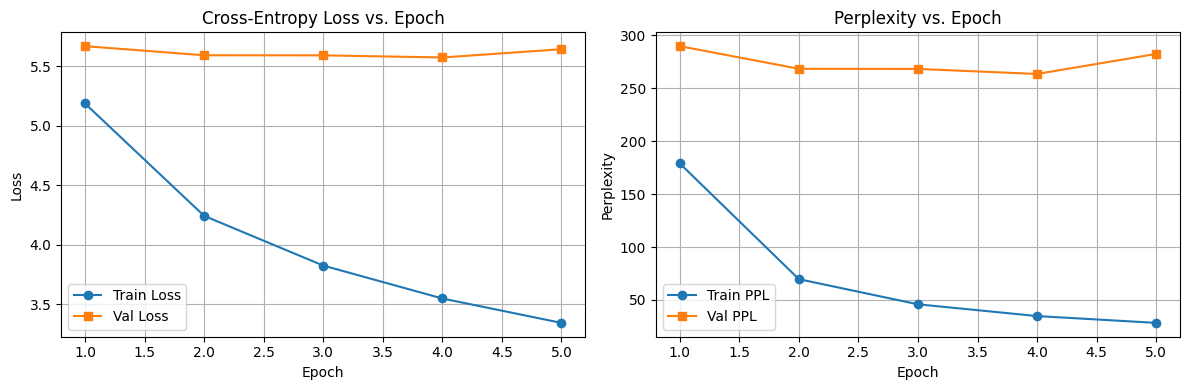

In [58]:
# Plot loss and perplexity learning curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], label="Train Loss", marker='o')
plt.plot(range(1, len(history["val_loss"]) + 1), history["val_loss"], label="Val Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss vs. Epoch")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history["train_ppl"]) + 1), history["train_ppl"], label="Train PPL", marker='o')
plt.plot(range(1, len(history["val_ppl"]) + 1), history["val_ppl"], label="Val PPL", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity vs. Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

After trainingmultiple epochs the best validation score model parameters are saved in `subtask2_attention_lstm_best.pt`.

For the subsequent evaluation and inference experiments we reload this as training a model everytime takes much time(here every epoch has taken atleast 90min).

In [ ]:


source = Path(r"/kaggle/input/datasets/bhuvanvishaljuturu/attention0000000/subtask2_attention_lstm_best")
output = Path("subtask2_attention_lstm_best.pt")

with zipfile.ZipFile(output, "w", compression=zipfile.ZIP_STORED) as z:
    for file in source.rglob("*"):
        if file.is_file():
            z.write(file, file.relative_to(source.parent))

print("Created:", output)

Created: subtask2_attention_lstm_best.pt


In [29]:
checkpoint_path = "subtask2_attention_lstm_best.pt"

In [57]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint)
model.eval()

print("✓ Trained checkpoint loaded successfully")
print("Device:", device)

✓ Trained checkpoint loaded successfully
Device: cuda


In [58]:
# Load best checkpoint and evaluate on test set
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Loaded best model weights from {checkpoint_path}")

test_loss = evaluate_loss(model, test_loader, criterion)
f"| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(min(test_loss, 100)):7.3f} |"

Loaded best model weights from subtask2_attention_lstm_best.pt


'| Test Loss: 4.941 | Test PPL: 139.846 |'

--- 
## 8. Decoding Strategies Comparison (SUBTASK 2 Core Requirement)

Subtask 2 explicitly calls for comparing alternative **decoding strategies** at inference:

### 1. Greedy Search Decoding
Picks the single most probable token $y_t = \arg\max_{w \in \mathcal{V}} P(w | y_{<t}, X)$ at each step. While $O(T \cdot V)$ fast, it is non-backtracking and easily gets stuck in locally suboptimal or repetitive generation loops.

### 2. Beam Search Decoding
Maintains a beam of $K$ partial hypotheses, tracking accumulated log-probabilities:
$$\text{Score}(Y) = \frac{1}{|Y|^\alpha} \sum_{t=1}^{|Y|} \log P(y_t | y_{<t}, X)$$
where $\alpha \in [0.6, 0.8]$ is a length penalty parameter preventing the search from artificially favoring short sentences.

### 3. Top-$k$ / Temperature Stochastic Sampling
Samples from temperature-scaled logits over the top-$k$ candidate tokens:
$$P(w) = \frac{\exp(z_w / T)}{\sum_{w' \in \text{Top-}k} \exp(z_{w'} / T)}$$
where $T < 1.0$ sharpens probabilities toward high-confidence words while permitting lexical diversity.

--- 
## 7. Autoregressive Inference & Attention Matrix Visualization

We extract the attention weight matrix $\alpha \in \mathbb{R}^{T_y \times T_x}$ during autoregressive generation and plot heatmaps to visually verify soft alignment between English source words and French generated words.

In [ ]:
def translate_sentence(
    sentence,
    model,
    src_vocab,
    trg_vocab,
    device,
    max_len=50
):
    """
    Translates an English sentence into French using greedy decoding.
    Returns predicted tokens, source tokens, and the attention matrix.
    """
    model.eval()

    if isinstance(sentence, str):
        tokens = tokenize(sentence)
    else:
        tokens = sentence

    src_ids = src_vocab.numericalize(tokens,add_sos=True,add_eos=True)

    src_tensor = torch.tensor(
        src_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(1)  # [src_len, 1]

    # Encoder
    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    trg_ids = [SOS_IDX]
    attentions = []

    # Greedy decoding
    for _ in range(max_len):

        trg_tensor = torch.tensor([trg_ids[-1]],dtype=torch.long,device=device)

        with torch.no_grad():
            output, hidden, cell, attention = model.decoder(
                trg_tensor,
                hidden,
                cell,
                encoder_outputs
            )

        attentions.append(
            attention.cpu().numpy()
        )

        pred_token = output.argmax(1).item()
        trg_ids.append(pred_token)

        if pred_token == EOS_IDX:
            break

    pred_tokens = [
        trg_vocab.itos.get(idx, UNK_TOKEN)
        for idx in trg_ids
        if idx not in (SOS_IDX, EOS_IDX)
    ]

    pred_sentence = " ".join(pred_tokens)

    # Source token labels for attention visualization
    src_tokens = [SOS_TOKEN] + tokens + [EOS_TOKEN]

    attention_matrix = np.concatenate(
        attentions,
        axis=0
    )

    return (pred_tokens,pred_sentence,src_tokens,attention_matrix)

In [ ]:
def translate_beam_search(sentence,
model,
src_vocab,trg_vocab,device,
beam_size=3,max_len=50,length_penalty=0.7):
    model.eval()

    if isinstance(sentence, str):
        tokens = tokenize(sentence)
    else:
        tokens = sentence

    src_ids = src_vocab.numericalize(
        tokens,
        add_sos=True,
        add_eos=True
    )

    src_tensor = torch.tensor(
        src_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(1)

    # Encode
    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    # Each beam:(cumulative_log_prob, token_ids, hidden, cell)
    beams = [(0.0, [SOS_IDX], hidden, cell)]

    for step in range(max_len):
        candidates = []
        all_completed = True

        for score, token_ids, h, c in beams:

            last_token = token_ids[-1]

            # Keep completed beams unchanged
            if last_token == EOS_IDX:
                candidates.append((score, token_ids, h, c))
                continue

            all_completed = False

            inp = torch.tensor([last_token],dtype=torch.long,device=device)

            with torch.no_grad():
                output, next_h, next_c, _ = model.decoder(inp,h,c,encoder_outputs)

            log_probs = F.log_softmax(output,dim=-1).squeeze(0)

            topk_probs, topk_tokens = torch.topk(log_probs,beam_size)

            for k in range(beam_size):

                cand_tok = topk_tokens[k].item()
                cand_prob = topk_probs[k].item()

                candidates.append((score + cand_prob,token_ids + [cand_tok],next_h,next_c))

        if all_completed:
            break

        # Length-normalized score
        def norm_score(item):
            s, tok_list, _, _ = item

            lp = ((5.0 + len(tok_list)) / 6.0) ** length_penalty

            return s / lp

        candidates.sort(key=norm_score,reverse=True)

        beams = candidates[:beam_size]

    # Select best beam
    best_score, best_tokens, _, _ = max(
        beams,
        key=lambda x:
            x[0] /
            (((5.0 + len(x[1])) / 6.0)
                ** length_penalty))

    pred_tokens = [
        trg_vocab.itos.get(idx,UNK_TOKEN)
        for idx in best_tokens
        if idx not in (SOS_IDX, EOS_IDX)
    ]

    normalized_score = (
        best_score /
        (
            ((5.0 + len(best_tokens)) / 6.0)
            ** length_penalty
        )
    )

    return (pred_tokens," ".join(pred_tokens),normalized_score)

In [ ]:
def translate_topk_sample(
    sentence,
    model,
    src_vocab,trg_vocab,
    device,
    temperature=0.7,top_k=10,max_len=50):
    
    model.eval()

    if isinstance(sentence, str):
        tokens = tokenize(sentence)
    else:
        tokens = sentence

    src_ids = src_vocab.numericalize(tokens,add_sos=True,add_eos=True)

    src_tensor = torch.tensor(src_ids,dtype=torch.long,device=device).unsqueeze(1)

    # Encoder
    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    trg_ids = [SOS_IDX]
    cum_log_prob = 0.0

    for _ in range(max_len):

        inp = torch.tensor([trg_ids[-1]],dtype=torch.long,device=device)

        with torch.no_grad():
            output, hidden, cell, _ = model.decoder(
                inp,
                hidden,cell,
                encoder_outputs
            )

        logits = output.squeeze(0) / max(temperature,1e-4)

        if top_k > 0:
            v, _ = torch.topk(logits,min(top_k, logits.size(-1)))

            logits[logits < v[-1]] = -float("Inf")

        probs = F.softmax(logits, dim=-1)

        pred_tok = torch.multinomial(probs,num_samples=1).item()

        # Log probability of selected token
        log_prob = F.log_softmax(output,dim=-1).squeeze(0)[pred_tok].item()

        cum_log_prob += log_prob

        trg_ids.append(pred_tok)

        if pred_tok == EOS_IDX:
            break

    pred_tokens = [trg_vocab.itos.get(idx,UNK_TOKEN)
        for idx in trg_ids
        if idx not in (SOS_IDX, EOS_IDX)]

    normalized_score = (cum_log_prob /(len(trg_ids) ** 0.7))

    return (pred_tokens," ".join(pred_tokens),normalized_score)

In [65]:
def bleu_for_strategy(decode_fn, df, n=200, **kwargs):
    smoother = SmoothingFunction().method1
    refs, hyps = [], []
    for _, row in df.iloc[:n].iterrows():
        out = decode_fn(row['en'], model, en_vocab, fr_vocab, device, **kwargs)
        pred_tokens = out[0]
        refs.append([tokenize(row['fr'])])
        hyps.append(pred_tokens)
    return {
        "BLEU-1": corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=smoother)*100,
        "BLEU-2": corpus_bleu(refs, hyps, weights=(.5,.5,0,0), smoothing_function=smoother)*100,
        "BLEU-4": corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=smoother)*100,
    }

strategies = {
    "Greedy":               (translate_sentence,     {}),
    "Beam K=3":             (translate_beam_search,  {"beam_size": 3}),
    "Beam K=5":             (translate_beam_search,  {"beam_size": 5}),
    "Top-k (k=10, T=0.7)":  (translate_topk_sample,  {"temperature": 0.7, "top_k": 10}),
}

rows = []
for name, (fn, kw) in strategies.items():
    t0 = time.time()
    scores = bleu_for_strategy(fn, test_df, n=200, **kw)
    scores["Strategy"] = name
    scores["Time (s)"] = round(time.time() - t0, 1)
    rows.append(scores)

decoding_bleu_df = pd.DataFrame(rows)[["Strategy", "BLEU-1", "BLEU-2", "BLEU-4", "Time (s)"]]
decoding_bleu_df.round(2)

,Strategy,BLEU-1,BLEU-2,BLEU-4,Time (s)
0,Greedy,45.94,31.16,16.37,6.8
1,Beam K=3,49.35,35.16,20.08,20.9
2,Beam K=5,49.16,35.15,20.34,35.4
3,"Top-k (k=10, T=0.7)",44.09,26.55,11.59,7.5


In [67]:
# Decoding strategy comparison on sample sentences
samples_to_test = [
    test_df.iloc[0]['en'],
    test_df.iloc[2]['en'],
]

rows = []
for s_en in samples_to_test:
    label = s_en[:50] + "..." if len(s_en) > 50 else s_en

    # 1. Greedy
    g_tokens, g_text, _, _ = translate_sentence(s_en, model, en_vocab, fr_vocab, device)
    rows.append({"Example": label, "Strategy": "Greedy (argmax)", "Translation": g_text})

    # 2. Beam K=3
    b3_tokens, b3_text, b3_score = translate_beam_search(s_en, model, en_vocab, fr_vocab, device, beam_size=3)
    rows.append({"Example": label, "Strategy": "Beam (K=3)", "Translation": b3_text})

    # 3. Beam K=5
    b5_tokens, b5_text, b5_score = translate_beam_search(s_en, model, en_vocab, fr_vocab, device, beam_size=5)
    rows.append({"Example": label, "Strategy": "Beam (K=5)", "Translation": b5_text})

    # 4. Top-k Sampling
    s_tokens, s_text, s_score = translate_topk_sample(s_en, model, en_vocab, fr_vocab, device, temperature=0.7, top_k=10)
    rows.append({"Example": label, "Strategy": "Top-k (k=10, T=0.7)", "Translation": s_text})

decoding_comparison_df = pd.DataFrame(rows)
decoding_comparison_df

,Example,Strategy,Translation
0,"Several years ago here at TED, Peter Skillman ...",Greedy (argmax),"plusieurs années ici , à ted , <unk> <unk> a u..."
1,"Several years ago here at TED, Peter Skillman ...",Beam (K=3),"il y a plusieurs années à ted , <unk> <unk> a ..."
2,"Several years ago here at TED, Peter Skillman ...",Beam (K=5),"il y a plusieurs années à ted , <unk> <unk> a ..."
3,"Several years ago here at TED, Peter Skillman ...","Top-k (k=10, T=0.7)","plusieurs y a plusieurs années à ted , <unk> <..."
4,The marshmallow has to be on top.,Greedy (argmax),nous a sur .
5,The marshmallow has to be on top.,Beam (K=3),c ' est sur .
6,The marshmallow has to be on top.,Beam (K=5),c ' est parti .
7,The marshmallow has to be on top.,"Top-k (k=10, T=0.7)",nous devons en . .



## 9. Evaluation 
After comparing Greedy search decoding,Beam search(k=3),Beam search(k=5) and Top-k(k=10),both beam search with k=3 and k=5 have significantly high BLEU scores than Greedy search and Top-k.From the examples camparing decoding strategy we observed that k=5 performs slightly better than k=3.So we evaluate the test set with beam search.

In [ ]:
def calculate_bleu(
    model,
    test_dataframe,
    src_vocab,trg_vocab,
    device,
    max_samples=1000,beam_size=5):
    """
    Computes corpus-level BLEU scores using Beam Search.
    """

    model.eval()

    eval_df = (
        test_dataframe.iloc[:max_samples]
        if max_samples
        else test_dataframe
    )

    references = []
    hypotheses = []

    smoother = SmoothingFunction().method1

    start_t = time.time()

    for idx, row in eval_df.iterrows():

        src_text = row['en']
        ref_text = row['fr']

        # Reference translation
        ref_tokens = tokenize(ref_text)

        # Beam Search decoding
        pred_tokens, _, _ = translate_beam_search(
            src_text,
            model,
            src_vocab,
            trg_vocab,
            device,
            beam_size=beam_size
        )

        references.append([ref_tokens])
        hypotheses.append(pred_tokens)

    total_time = time.time() - start_t

    # BLEU scores
    b1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1.0, 0, 0, 0),
        smoothing_function=smoother
    ) * 100

    b2 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smoother
    ) * 100

    b3 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.33, 0.33, 0.34, 0),
        smoothing_function=smoother
    ) * 100

    b4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoother
    ) * 100

    print(
        f"\nBeam Search (K={beam_size}) "
        f"BLEU Evaluation "
        f"({len(eval_df):,} examples evaluated in {total_time:.1f}s):"
    )

    print("+" + "-" * 20 + "+" + "-" * 15 + "+")
    print(f"| {'Metric':<18} | {'Score (%)':<13} |")
    print("+" + "-" * 20 + "+" + "-" * 15 + "+")

    print(f"| {'BLEU-1':<18} | {b1:<13.2f} |")
    print(f"| {'BLEU-2':<18} | {b2:<13.2f} |")
    print(f"| {'BLEU-3':<18} | {b3:<13.2f} |")
    print(f"| {'BLEU-4 (Cumulative)':<18} | {b4:<13.2f} |")

    print("+" + "-" * 20 + "+" + "-" * 15 + "+")

    return {
        "bleu_1": b1,
        "bleu_2": b2,
        "bleu_3": b3,
        "bleu_4": b4,
        "hypotheses": hypotheses,
        "references": references
    }
bleu_results = calculate_bleu(
    model,
    test_df,
    en_vocab,
    fr_vocab,
    device,
    max_samples=1000,
    beam_size=5


)


Beam Search (K=5) BLEU Evaluation (1,000 examples evaluated in 193.7s):
+--------------------+---------------+
| Metric             | Score (%)     |
+--------------------+---------------+
| BLEU-1             | 48.95         |
| BLEU-2             | 35.33         |
| BLEU-3             | 26.48         |
| BLEU-4 (Cumulative) | 20.40         |
+--------------------+---------------+



## 10. No-Attention Baseline(SUBTASK1) vs. Bahdanau Attention



In [ ]:
best_valid_loss = 5.5736
subtask1_bleu1 = 31.56   
subtask1_bleu2 = 16.19   
subtask1_bleu3 = 9.51    
subtask1_bleu4 = 5.94    
subtask1_val_loss = 5.674  

comparison_data = {
    "Evaluation Metric": [
        "BLEU-1 (Unigram)",
        "BLEU-2 (Bigram)",
        "BLEU-3 (Trigram)",
        "BLEU-4 (Cumulative)",
        "Best Val Loss",
        "Best Val PPL",
    ],
    "Subtask 1: No Attention": [
        f"{subtask1_bleu1:.2f}%",
        f"{subtask1_bleu2:.2f}%",
        f"{subtask1_bleu3:.2f}%",
        f"{subtask1_bleu4:.2f}%",
        f"{subtask1_val_loss:.3f}",
        f"{math.exp(min(subtask1_val_loss, 100)):.2f}",
    ],
    "Subtask 2: Bahdanau Attention": [
        f"{bleu_results['bleu_1']:.2f}%",
        f"{bleu_results['bleu_2']:.2f}%",
        f"{bleu_results['bleu_3']:.2f}%",
        f"{bleu_results['bleu_4']:.2f}%",
        f"{best_valid_loss:.3f}",
        f"{math.exp(min(best_valid_loss, 100)):.2f}",
    ],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Evaluation Metric,Subtask 1: No Attention,Subtask 2: Bahdanau Attention
0,BLEU-1 (Unigram),31.56%,48.95%
1,BLEU-2 (Bigram),16.19%,35.33%
2,BLEU-3 (Trigram),9.51%,26.48%
3,BLEU-4 (Cumulative),5.94%,20.40%
4,Best Val Loss,5.674,5.574
5,Best Val PPL,291.20,263.38


--- 
## 11. Resolving the Information Bottleneck: BLEU vs. Sentence Length

We evaluate BLEU-4 by sentence length bucket to demonstrate that the Bahdanau attention model resolves the information bottleneck that degraded the basic encoder-decoder on long sentences.

In [72]:
# BLEU-4 by sentence length bucket
smoother = SmoothingFunction().method1

length_buckets = {"Short (<=10 words)": [], "Medium (11-25 words)": [], "Long (>25 words)": []}
bucket_refs = {"Short (<=10 words)": [], "Medium (11-25 words)": [], "Long (>25 words)": []}

eval_subset = test_df.iloc[:500]
for _, row in eval_subset.iterrows():
    src_text = row['en']
    ref_text = row['fr']
    src_tokens = tokenize(src_text)
    n_words = len(src_tokens)

    ref_tokens = tokenize(ref_text)
    pred_tokens, _, _, _ = translate_sentence(src_text, model, en_vocab, fr_vocab, device)

    if n_words <= 10:
        bucket = "Short (<=10 words)"
    elif n_words <= 25:
        bucket = "Medium (11-25 words)"
    else:
        bucket = "Long (>25 words)"

    length_buckets[bucket].append(pred_tokens)
    bucket_refs[bucket].append([ref_tokens])

print("BLEU-4 by Source Sentence Length (Bahdanau Attention):")
print("+" + "-"*25 + "+" + "-"*12 + "+" + "-"*10 + "+")
print(f"| {'Bucket':<23} | {'BLEU-4 (%)':<10} | {'Count':<8} |")
print("+" + "-"*25 + "+" + "-"*12 + "+" + "-"*10 + "+")
for bucket_name in ["Short (<=10 words)", "Medium (11-25 words)", "Long (>25 words)"]:
    if len(bucket_refs[bucket_name]) > 0:
        b4 = corpus_bleu(bucket_refs[bucket_name], length_buckets[bucket_name],
                         weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother) * 100
    else:
        b4 = 0.0
    print(f"| {bucket_name:<23} | {b4:<10.2f} | {len(length_buckets[bucket_name]):<8} |")
print("+" + "-"*25 + "+" + "-"*12 + "+" + "-"*10 + "+")

BLEU-4 by Source Sentence Length (Bahdanau Attention):
+-------------------------+------------+----------+
| Bucket                  | BLEU-4 (%) | Count    |
+-------------------------+------------+----------+
| Short (<=10 words)      | 11.20      | 124      |
| Medium (11-25 words)    | 15.28      | 266      |
| Long (>25 words)        | 17.66      | 110      |
+-------------------------+------------+----------+


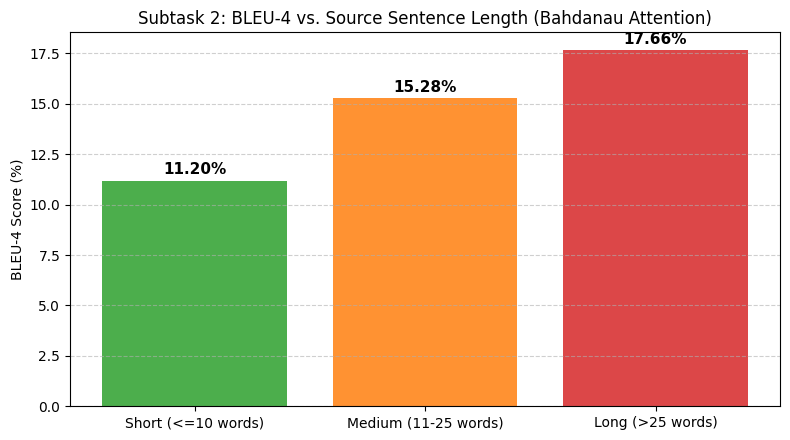

In [73]:
# Visualize BLEU-4 vs. sentence length
bucket_names = list(length_buckets.keys())
bleu_scores = []
for bn in bucket_names:
    if len(bucket_refs[bn]) > 0:
        b4 = corpus_bleu(bucket_refs[bn], length_buckets[bn],
                         weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother) * 100
    else:
        b4 = 0.0
    bleu_scores.append(b4)

plt.figure(figsize=(8, 4.5))
bars = plt.bar(bucket_names, bleu_scores, color=['#2ca02c', '#ff7f0e', '#d62728'], alpha=0.85)
for bar, score in zip(bars, bleu_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{score:.2f}%", ha='center', fontweight='bold', fontsize=11)
plt.ylabel("BLEU-4 Score (%)")
plt.title("Subtask 2: BLEU-4 vs. Source Sentence Length (Bahdanau Attention)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 12. CONCLUSION

BLEU-4 vs Sentence Length plot we observed the model predicts better for long sentences, so we can say that attention mechanisms solves the information bottleneck problem.

We also observed that attention mechanism performs better than basic encoder-decoder architecture as BLUE scores for attention architecture is significantly greater than basic encoder-decoder architecture.